<font color='87BAC3'>**Medical Cost Personal Dataset**</font>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df=pd.read_csv("insurance-2.csv")

<font color='87BAC3'>**Data Preprocessing**</font>

In [4]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df = df.drop_duplicates()

In [10]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [11]:
x=df_encoded.drop('charges',axis=1)
y=df_encoded['charges']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

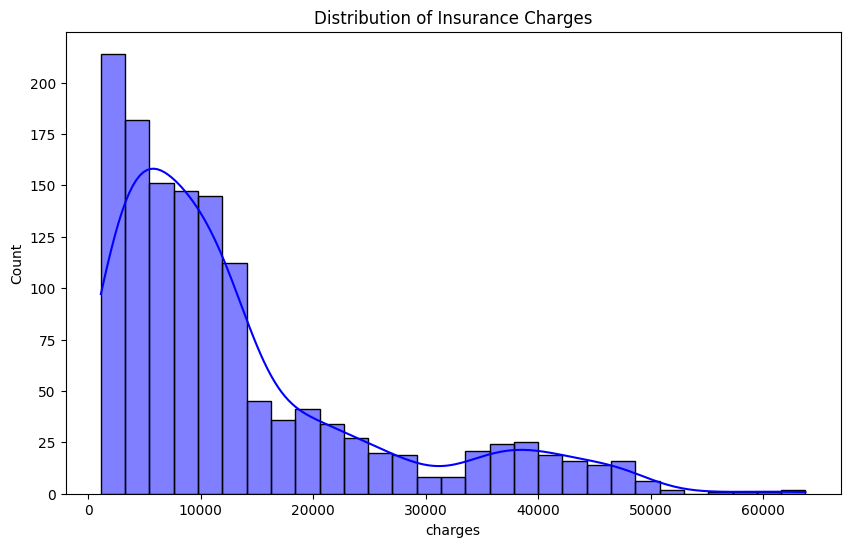

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')
plt.show()

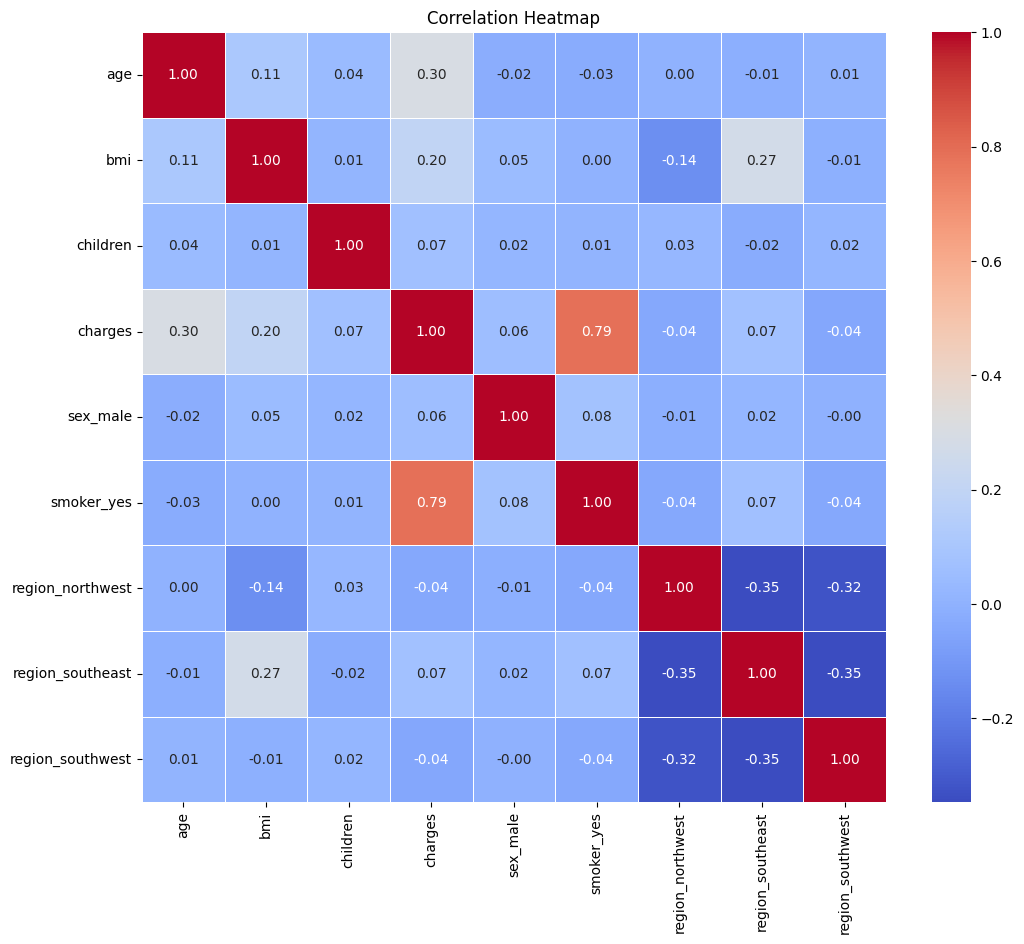

In [15]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

<font color='87BAC3'>**Baseline Model 1 (128 neurons)**</font>

In [17]:
def build_baseline_model():
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mae",
        metrics=["mae"]
    )
    return model

baseline_model = build_baseline_model()
history = baseline_model.fit(x_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)
best_loss = min(history.history['val_loss'])
print(f"Best MAE: ${best_loss:.2f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 13134.6465 - mae: 13134.6465 - val_loss: 12603.4648 - val_mae: 12603.4648
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 13129.0586 - mae: 13129.0586 - val_loss: 12595.1465 - val_mae: 12595.1465
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 13116.6270 - mae: 13116.6270 - val_loss: 12577.5254 - val_mae: 12577.5254
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 13091.8027 - mae: 13091.8027 - val_loss: 12544.3652 - val_mae: 12544.3652
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 13047.8154 - mae: 13047.8154 - val_loss: 12488.6025 - val_mae: 12488.6025
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12977.0137 - mae: 12977.0137 - val_loss: 12402.7188 - val_mae: 12402.7188
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12872.1221 - mae: 12872.1221 - val_loss: 12279.4160 - val_mae: 12279.4160
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 12725.0068 - mae: 12

<font color='99AD7A'>**The model predicts insurance costs with an average error of $3227**</font>

<font color='87BAC3'>**Model 2 (64 neurons)**</font>

In [28]:
def build_model64():
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mae",
        metrics=["mae"]
    )
    return model

baseline_model2 = build_model64()
history = baseline_model2.fit(x_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)
best_mae_baseline = min(history.history['val_loss'])
print(f"Best MAE: ${best_mae_baseline:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 13135.0234 - mae: 13135.0234 - val_loss: 12604.9932 - val_mae: 12604.9932
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13132.5801 - mae: 13132.5801 - val_loss: 12601.7344 - val_mae: 12601.7344
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13127.9346 - mae: 13127.9346 - val_loss: 12595.4678 - val_mae: 12595.4678
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13119.5195 - mae: 13119.5195 - val_loss: 12584.7129 - val_mae: 12584.7129
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13105.5215 - mae: 13105.5215 - val_loss: 12567.3438 - val_mae: 12567.3438
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13083.8721 - mae: 13083.8721 - val_loss: 12541.4004 - val_mae: 12541.4004
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13052.3740 - mae: 13052.3740 - val_loss: 12504.7344 - val_mae: 12504.7344
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13008.9609 - mae:

<font color='99AD7A'>**Model 1 (128 neurons) outperformed Model 2 (64 neurons). mae=3827**</font>

<font color='87BAC3'>**Optimizers**</font>

In [19]:
def build_model(optimizer):
    model = keras.Sequential([
        keras.layers.Input(shape=(x_train_scaled.shape[1],)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=optimizer,
        loss="mae",
        metrics=["mae"]
    )
    return model

optimizers = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "SGD Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": keras.optimizers.Adam(learning_rate=0.001)
}

results = {}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")
    model = build_model(opt)
    history = model.fit(x_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)
    loss, mae = model.evaluate(x_test_scaled, y_test, verbose=0)
    results[name] = mae
    print(f"{name} Mean Absoulate Error: {mae:.4f}")

results


Training with SGD
SGD Mean Absoulate Error: 2797.8423

Training with SGD Momentum
SGD Momentum Mean Absoulate Error: 3948.0425

Training with RMSProp
RMSProp Mean Absoulate Error: 4163.1387

Training with Adam
Adam Mean Absoulate Error: 3697.1824


{'SGD': 2797.84228515625,
 'SGD Momentum': 3948.04248046875,
 'RMSProp': 4163.138671875,
 'Adam': 3697.182373046875}

<font color='99AD7A'>**SGD is the best one. Mae=2797**</font>

<font color='87BAC3'>**Testing learning rates**</font>


In [21]:
learning_rates = [0.1,0.01,0.001]
lr_results = {}

for lr in learning_rates:
    print(f"Testing Learning Rate: {lr}")

    model = keras.Sequential([keras.layers.Input(shape=(x_train_scaled.shape[1],)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1)
    ])

    optimizer = keras.optimizers.SGD(learning_rate=lr)
    model.compile(optimizer=optimizer, loss="mae")

    model.fit(x_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)

    mae = model.evaluate(x_test_scaled, y_test, verbose=0)
    lr_results[lr] = mae
    print(f"LR {lr} -> MAE: {mae:.2f}")



Testing Learning Rate: 0.1
LR 0.1 -> MAE: 14104.74
Testing Learning Rate: 0.01
LR 0.01 -> MAE: 3151.84
Testing Learning Rate: 0.001
LR 0.001 -> MAE: 3433.55


<font color='99AD7A'>**Best learning rate is 0.01**</font>


<font color='87BAC3'>**Dropout**</font>


In [29]:
def build_dropout_model():
    model = keras.Sequential([
        keras.layers.Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="mae",
        metrics=["mae"]
    )
    return model

dropout_model = build_dropout_model()
history_dropout = dropout_model.fit(x_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)
best_mae_baseline = min(history_dropout.history['val_loss'])
print(f"Best MAE: ${best_mae_baseline:.2f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 13135.2412 - mae: 13135.2412 - val_loss: 12605.1260 - val_mae: 12605.1260
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13132.3496 - mae: 13132.3496 - val_loss: 12600.1973 - val_mae: 12600.1973
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13121.1201 - mae: 13121.1201 - val_loss: 12574.1553 - val_mae: 12574.1553
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12953.9248 - mae: 12953.9248 - val_loss: 11595.0654 - val_mae: 11595.0654
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6618.1221 - mae: 6618.1221 - val_loss: 3888.2568 - val_mae: 3888.2568
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4517.0034 - mae: 4517.0034 - val_loss: 3655.4119 - val_mae: 3655.4119
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4278.6470 - mae: 4278.6470 - val_loss: 3401.1848 - val_mae: 3401.1848
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4108.7739 - mae: 4108.7739 - val_loss: 3

<font color='87BAC3'>**Early Stopping**</font>


In [30]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

model = build_baseline_model()
history_es = model.fit(
    x_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 13135.1562 - mae: 13135.1562 - val_loss: 12604.4824 - val_mae: 12604.4824
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13131.0156 - mae: 13131.0156 - val_loss: 12598.4531 - val_mae: 12598.4531
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13121.7080 - mae: 13121.7080 - val_loss: 12585.1924 - val_mae: 12585.1924
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13102.5107 - mae: 13102.5107 - val_loss: 12559.3105 - val_mae: 12559.3105
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13067.4014 - mae: 13067.4014 - val_loss: 12514.3926 - val_mae: 12514.3926
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13009.1729 - mae: 13009.1729 - val_loss: 12443.3438 - val_mae: 12443.3438
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12920.8945 - mae: 12920.8945 - val_loss: 12339.0664 - val_mae: 12339.0664
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12794.7041 - mae: 12794.7041

<font color='99AD7A'>**mae=3254**</font>


<font color='87BAC3'>**Final Evaluation**</font>

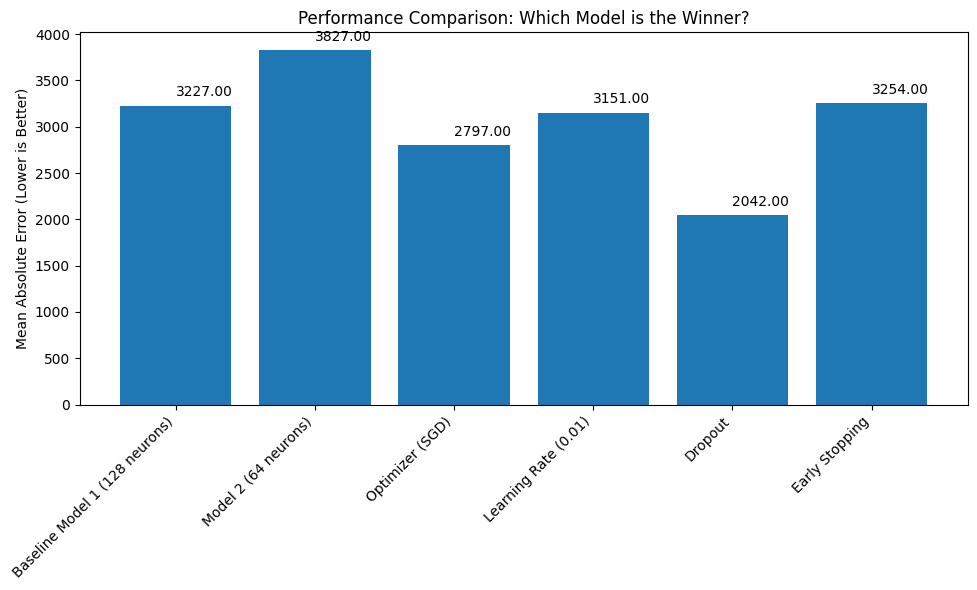

In [39]:
data = {
    'Experiment': [
        'Baseline Model 1 (128 neurons)',
        'Model 2 (64 neurons)',
        'Optimizer (SGD)',
        'Learning Rate (0.01)',
        'Dropout',
        'Early Stopping'
    ],
    'Best Validation MAE': [
        3227,
        3827,
        2797,
        3151,
        2042,
        3254
    ]
}

performance_df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
bars = plt.bar(performance_df['Experiment'], performance_df['Best Validation MAE'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval:.2f}')

plt.title('Performance Comparison: Which Model is the Winner?')
plt.ylabel('Mean Absolute Error (Lower is Better)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()